# Reinforcement learning tutorial

Prepared by Mihály Bányai, 2026. mihaly.s.banyai@gmail.com, https://visionlab-ceu.org/people/mihaly-banyai/ 

The first block, after the imports, implements a plotting function that we will use to see what our algorithms learned in the example problems. It's been largely written by an LLM, and it does not contain any scientific of algorithmic solutions, but feel free to look into it or adapt it to your purposes.

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

def plot_gridworld(
    grid,
    init_state,
    q_function=None,
    value_function=None,
    cmap_cells="viridis",
    cmap_q="coolwarm",
    arrow_scale=0.25,
    wall_color="lightgray",
):
    """
    Plot a gridworld with walls, rewarded cells, and an initial state. Written mostly by ChatGPT.

    grid : array-like, shape (n, m)
        0 = normal state
        1 = wall
        3 = rewarded cell (red border)
    value_function : array-like, shape (n*m,) or (n*m, 1)
        State value function (row-major).
    q_function : array-like, shape (n*m, 4)
        Q-values per state in order: [left, up, right, down].
    init_state : int
        Initial state index (row-major), highlighted in yellow.
    """
    grid = np.asarray(grid)
    n, m = grid.shape

    noplot_q = False
    if q_function is None:
        noplot_q = True
        q_function = np.zeros((n * m, 4))
    Q = np.asarray(q_function)
    if value_function is None:
        value_function = Q.max(axis=1)
    V = np.asarray(value_function).reshape(-1)
   

    if V.size != n * m:
        raise ValueError("Value function must have size n*m")
    if Q.shape != (n * m, 4):
        raise ValueError("Q function must have shape (n*m, 4)")
    if not (0 <= init_state < n * m):
        raise ValueError("init_state out of bounds")

    # Mask walls for value coloring
    V_grid = V.reshape(n, m)
    V_masked = np.ma.masked_where(grid == 1, V_grid)

    fig, ax = plt.subplots()
    im = ax.imshow(V_masked, cmap=cmap_cells, origin="upper")

    # Grid lines
    ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linewidth=1)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

    # Draw walls
    for i in range(n):
        for j in range(m):
            if grid[i, j] == 1:
                ax.add_patch(
                    Rectangle((j - 0.5, i - 0.5), 1, 1,
                              facecolor=wall_color, edgecolor="black")
                )

    # Normalize Q-values
    q_min, q_max = Q.min(), Q.max()
    norm = plt.Normalize(q_min, q_max)
    q_cmap = plt.get_cmap(cmap_q)

    # Action directions: left, up, right, down
    directions = {
        0: (-arrow_scale, 0),   # left
        1: (0, -arrow_scale),   # up
        2: (arrow_scale, 0),    # right
        3: (0, arrow_scale),    # down
    }

    for s in range(n * m):
        i, j = divmod(s, m)

        if grid[i, j] == 1:
            continue  # wall

        cx, cy = j, i

        if not noplot_q:
            # Draw Q arrows
            for a in range(4):
                dx, dy = directions[a]
                color = q_cmap(norm(Q[s, a]))

                ax.arrow(
                    cx, cy,
                    dx, dy,
                    width=0.02,
                    head_width=0.08,
                    head_length=0.08,
                    length_includes_head=True,
                    color=color,
                    alpha=0.9,
                )

        # Rewarded cell border
        if grid[i, j] == 3:
            ax.add_patch(
                Rectangle((j - 0.5, i - 0.5), 1, 1,
                          fill=False, edgecolor="red", linewidth=3)
            )

    # Initial state border (draw last so it’s visible)
    init_i, init_j = divmod(init_state, m)
    if grid[init_i, init_j] != 1:
        ax.add_patch(
            Rectangle((init_j - 0.5, init_i - 0.5), 1, 1,
                      fill=False, edgecolor="yellow", linewidth=3)
        )

    # Colorbars
    plt.colorbar(im, ax=ax, label="V(s)")
    if not noplot_q:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=q_cmap)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="Q(s,a)")

    plt.show()

## Temporal difference learning

The basic equation to iteratively update a value function in a passive environment, solving the credit assigmnent problem without learning model of state transitions:

$V(s_t) \leftarrow V(s_t) + \alpha \left(R_{t+1} + \gamma V(s_{t+1}) - V(s_t) \right)$

To see how this works, we use a state space I call "the conveyor belt". It starts out in an initial state, an with a fixed (small) probability, it can transition into a "cue state", that indicates that the reward is a fixed $k$ number of steps away (initially this number is unknown to the agent). Then the agent deterministically proceeds through $k$ states, and then into a rewarded state, then back to the initial one.

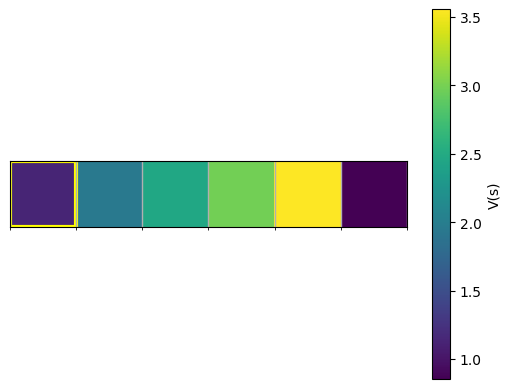

In [ ]:
def conveyor_belt_state_space(n_states, cue_probability):
    assert cue_probability  <= 1. and cue_probability  >= 0.
    
    # this is just for illustration purposes
    map_cb = [[0] * n_states]
    map_cb[0][-1] = cue_probability
    
    # we construct the state transition probability matrix
    T = np.zeros((n_states, n_states))
    T[0, 1] = cue_probability
    T[0, 0] = 1. - cue_probability
    for s in range(1, n_states-1):
        T[s, s+1] = 1
    T[-1, 0] = 1

    # and the reward function
    R = np.zeros((n_states))
    R[-1] = 3

    return T, R, map_cb


def temporal_difference_learning(T, R, n_step, gamma, alpha):
    n_states = R.shape[0]
    states = list(range(n_states))
    V = np.zeros(n_states)
    td_errors = np.zeros((n_step, 2))
    act_state = 0
    for i in range(n_step):
        # this chooses the next state according to the transition probabilities
        next_state = np.random.choice(states, size=1, p=T[act_state, :].flatten()).item()
        reward = R[next_state]

        TD = reward + gamma * V[next_state] - V[act_state]
        td_errors[i, 0] = act_state
        td_errors[i, 1] = TD 
        V[act_state] += alpha * TD

        act_state = next_state
    return V, td_errors

T_conv, R_conv, map_conv = conveyor_belt_state_space(6, cue_probability=0.3)
V, td_errors = temporal_difference_learning(T_conv, R_conv, 500, 0.9, 0.1)
plot_gridworld(map_conv, 0, value_function=V)

### Shift of prediction errors from reward to cue

An empirical fact about dopamine neurons is that at the beginning of learning they tend to activate when the reward is collected, but at the end of learning they activate when the cue comes on, and not at the reward. Let's see if we can reproduce this using TD learning!

Text(0, 0.5, 'TD error')

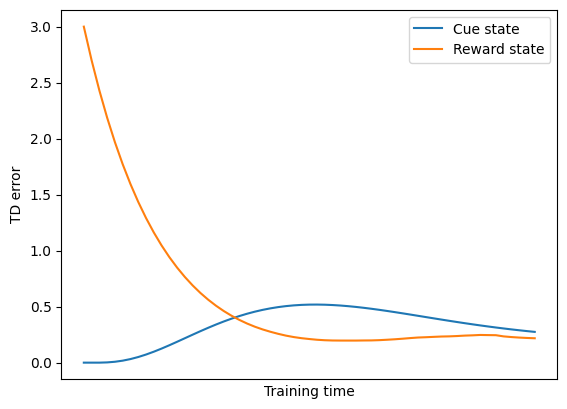

In [191]:
cue_state_idx = td_errors[:, 0] == 1
plt.plot(td_errors[cue_state_idx, 1], label="Cue state")
reward_state_idx = td_errors[:, 0] == T_conv.shape[0] - 2
plt.plot(td_errors[reward_state_idx, 1], label="Reward state")
plt.legend()
plt.xlabel("Training time")
plt.xticks([])
plt.ylabel("TD error")

## Independent work: negative prediction errors

Show that when the reward that the agent expects doesn't arrive, then we get a negative prediction error after learning, but not before - in accordance with the measurements from dopamine neurons.

- What do you have to change about the state space to be able to model this situation?
- What kind of plot will show this phenomenon?

In [ ]:
## plot here

## Learning the value of actions

In order to test Q-learning, we use a more complex state space. It is easier to define these as maps - the next block implements a function that constructs T and R from such a map.

In [199]:
def transition_probs_from_map(map, start_state):
    n_rows = len(map)
    n_cols = len(map[0])
    n_states = n_rows * n_cols
    n_actions = 4 # left, up, right, down
    action_neighbors = [(0, -1), (-1, 0), (0, 1), (1, 0)]
    T = np.zeros((n_states, n_states, n_actions))
    R = np.zeros((n_states))
    for row_idx, row in enumerate(map):
        for cell_idx, cell in enumerate(row):
            state_idx = row_idx * n_cols + cell_idx
            if cell > 1:
                R[state_idx] = cell
            for action in range(n_actions):
                if cell > 1:
                    T[state_idx, start_state, action] = 1.
                else:
                    target_row = row_idx + action_neighbors[action][0]
                    target_column = cell_idx + action_neighbors[action][1]
                    if target_row < 0 or target_row >= n_rows or target_column < 0 or target_column >= n_cols:
                        T[state_idx, state_idx, action] = 1.
                    else:
                        target_resistance = map[target_row][target_column] if map[target_row][target_column] <= 1 else 0
                        T[state_idx, state_idx, action] = target_resistance
                        target_state = target_row * n_cols + target_column
                        T[state_idx, target_state, action] = 1. - target_resistance
    return T, R

state_map = [
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 3]
]

init_state = 13
T_map, R_map = transition_probs_from_map(state_map, start_state=init_state)


Then we implement Q-learning, together with an avaluation function that we will use to check how well our algorithm is doing. We also intruduce a negative reward for each action, incentivising ahorter solutions.

The basic formula for Q-learning is this:

$Q_{t+1}(s_t, a_t) = (1 - \alpha) Q_t(s_t, a_t) + \alpha \left[ R(s_{t+1}, a_t) + \gamma \max_a Q_t(s_{t+1}, a) - Q_t(s_t, a_t)\right]$

And we use $\varepsilon$-greedy action selection rule, meaning that with probability $\varepsilon$ the agent chooses a random action, and with probability $1-\varepsilon$ the one with the highest $Q$-value.

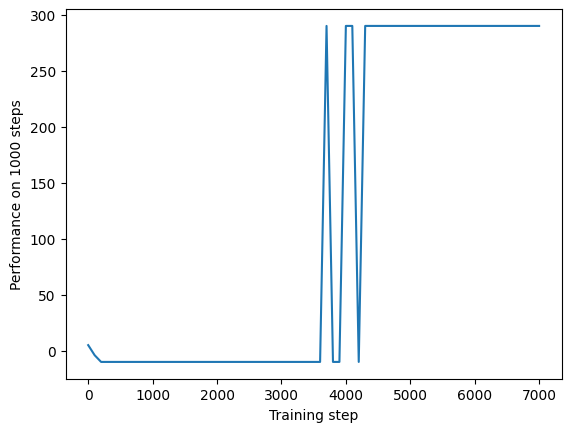

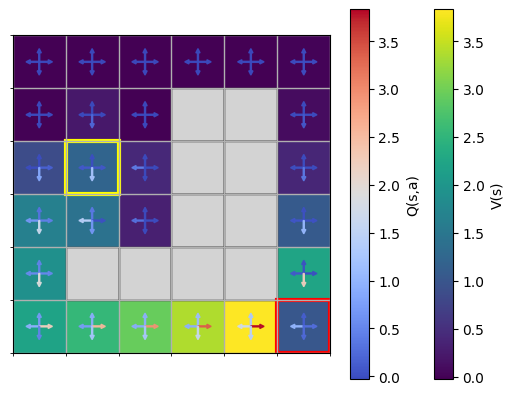

In [208]:
def evaluate_Q(T, R, init_state, Q, n_step, action_penalty=None):
    n_states = R.shape[0]
    states = list(range(n_states))

    collected_reward = 0
    act_state = init_state

    for _ in range(n_step):
        reward = R[act_state]
        reward += 0 if action_penalty is None else action_penalty
        collected_reward += reward

        # we always choose the highest value action, if there are multiple then randomly from those
        best_actions = np.argwhere(Q[act_state, :] == np.amax(Q[act_state, :])).flatten().tolist()
        action = random.choice(best_actions)
        act_state = np.random.choice(states, size=1, p=T[act_state, :, action].flatten()).item()
    return collected_reward


def Q_learning(T, R, gamma, max_iter, alpha, epsilon, init_state, Q_init=None, action_penalty=None, eval_interval=None, eval_step=1000):
    n_states = R.shape[0]
    n_actions = T.shape[2]
    states = list(range(n_states))
    actions = list(range(n_actions))

    Q = np.zeros((n_states, n_actions))
    if not Q_init is None:
        # we allow nonzero initialisations for Q functions as well
        Q = np.copy(Q_init)
    
    # we record the algorithm's convergence in multiple ways
    value_sums = [0]
    eval_perfs = [evaluate_Q(T, R, init_state, Q, eval_step, action_penalty=action_penalty) if eval_interval is not None else 0]
    
    act_state = init_state
    for i in range(max_iter):

        # the epsilon-greedy action selection rule
        if random.uniform(0, 1) < epsilon:
            action = random.choice(actions)
        else:
            best_actions = np.argwhere(Q[act_state, :] == np.amax(Q[act_state, :])).flatten().tolist()
            action = random.choice(best_actions)

        # the next state is chosen according to the state-action transition probability tensor
        next_state = np.random.choice(states, size=1, p=T[act_state, :, action].flatten()).item()

        # the reward is augmented with the action penalty
        reward = R[next_state]
        reward += 0 if action_penalty is None else action_penalty

        # the TD update uses the most valuable action in the next state
        TD = reward + gamma * Q[next_state, :].max()
        Q[act_state, action] = (1 - alpha) * Q[act_state, action] + alpha * TD

        # performance logging
        if eval_interval is not None and i % eval_interval == 0:
            eval_perfs.append(evaluate_Q(T, R, init_state, Q, eval_step, action_penalty=action_penalty))
        value_sums.append(Q.sum() / n_states)

        act_state = next_state
            
    if eval_interval is not None:
        plt.plot(np.array(range(len(eval_perfs))) * eval_interval , eval_perfs)
        plt.xlabel("Training step")
        plt.ylabel("Performance on %d steps" % eval_step)
        
    return value_sums, Q

_, Q = Q_learning(T_map, R_map, 0.9, 7000, 0.05, 0.2, init_state, action_penalty=-0.01, eval_interval=100, eval_step=1000)
plot_gridworld(state_map, init_state, q_function=Q)

## Independent work - the effect of the exploration rate and the discount factor

- what seems to be the systematic effect of chaning these two parameters?
- what is a plot that could confirm or falsify a hypothesis about these effects?

## Homework problems

### 1. Implement a simple version of the Go-Explore algorithm

- https://arxiv.org/abs/1901.10995 
- build a map with multiple smaller rewards, and some larger ones in such a way that the smaller ones help finding the large one
- the algorithm saves the good spots it found, then it goes back to one of those at the start of each episode, and then explores randomly
- compare the efficiency of such an algorithm to Q-learning

### 2. Non-Markovian environments

- build an environment in which state transitions depend on past states as well, e.g. on the last two the agent visited
- show that Q-learning does not converge in such an environment
- how can you transform such a state space into an equivalent Markovian one? Hint: it will have a lot more states.

### 3. A simple replay buffer

- extend the Q-learning algorithm in such a way that it saves state transitions into a buffer, and it replays them offline to update the Q function faster from fewer actual steps
- how much more efficient can you make the learning process?
- what is a good criterion to save a particular transition into the buffer?

### 4. Algorithm-specific representations?
- implement the example problem from Section 4.2 of Andrew McCallum's thesis https://neuro.bstu.by/ai/To-dom/My_research/Papers-0/For-research/R-navigation/Navigate-by-memory/thesis.pdf 
- implement the aliased variants
- use Q-learning to check the claim that the state space sufficient to represent the optimal solution is not sufficient to learn it